<a href="https://colab.research.google.com/github/Buraporn-Subsomboon/Buraporn_INFO4670_Spring26/blob/main/INFO4670_Assignment_SMS_Spam_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12: Assignment 4 — SMS Spam Detection

**Goal:** Apply the six-step classification workflow to a real dataset.
Predict whether an SMS message is spam or legitimate (ham) using text-based features.

---

## I. Assignment Objective

By completing this assignment, you will:
- Follow a complete classification pipeline on real-world data
- Engineer binary features from raw text
- Train and evaluate a Decision Tree and a Naive Bayes classifier
- Interpret a confusion matrix and choose the right evaluation metric
- Analyze model performance and reflect on possible improvements

---

## II. Dataset

**Source:** UCI SMS Spam Collection (5,572 real SMS messages, no login required)

| Column | Description | Example |
|---|---|---|
| `label` | Class label | `spam` or `ham` |
| `message` | Raw SMS text | "WINNER!! You have been selected..." |
| `spam` | Encoded label (1 = spam, 0 = ham) | 1 |

Load it with one line — no file upload needed:
```python
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
```

---

## III. Grading Rubric (Total = 100 points)

| Section | What is graded | Points |
|---|---|---|
| Step 1 — Problem definition | Q1a + Q1b + Q1c (written) | 10 |
| Step 2 — Explore the data | Code runs correctly (2B, 2C, 2D) | 15 |
| Step 3 — Feature engineering | Code (3B, 3C) + Q3a + Q3b + Q3c (written) | 20 |
| Step 4 — Split the data | Code (4A) + Q4a + Q4b (written) | 10 |
| Step 5 — Train models | Code: 5A + 5B + 5C + 5D (5 pts each) | 20 |
| Step 6 — Code (6A + 6B + 6C) | Each code block runs correctly (4 pts each) | 12 |
| Step 6 — Written (Q6a–Q6d) | Q6a (3) + Q6b (3) + Q6c (4) + Q6d (3) | 13 |
| **Total** | | **100** |

---

## IV. Steps to Complete

Follow the steps below in order.
Each code cell starts with `# Write your code here` — replace it with your implementation.


---
### Setup — Run this cell first (provided)

In [2]:
# This cell is provided — run it before starting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)
print('Setup complete!')


Setup complete!


---
## Step 1 — Define the Problem

Before writing any code, answer the questions below.
Your answers here should guide every metric decision you make in Step 6.

**Context:**
A mobile carrier wants an automated classifier to flag spam SMS messages
before they reach users. The two possible errors are:

| Error | What happens |
|---|---|
| False Positive | A real (ham) message gets blocked |
| False Negative | A spam message reaches the user |

### Q1 — Problem Definition *(10 points)*

**Q1a.** Which error is more costly in a real spam filter — False Positive or False Negative?
Give one concrete real-world consequence for each.

*Your answer:*
> A false positive is usually more costly in a real spam filter because it blocks legitimate messages that users may need. For example, a false positive could cause someone to miss an important text, such as a bank fraud alert, a message about a job interview, or a reminder about a doctor’s appointment. A false negative means a spam message gets through to the user. Consequences could include receiving a phishing text, scam link, or other unwanted message that wastes time or may lead to fraud.

**Q1b.** Based on Q1a, which metric should be your primary evaluation target?
Choose one: **Precision**, **Recall**, or **F1-Score**. Explain why.

*Your answer:*
> My primary evaluation target would be precision.
Precision measures the percentage of messages predicted as spam that are actually spam. This is the best choice because, if false positives are costly, we must be careful not to incorrectly label real messages as spam. A high precision rate means that when the model blocks a message, it is usually correct.

**Q1c.** The spam rate in this dataset is about 13%.
What accuracy would a dummy model that always predicts "ham" achieve?
Is that number still misleading? Why?

*Your answer:*
> If about 13% of the dataset is spam, then approximately 87% is ham. Therefore, a dummy model that always predicts "ham" would achieve about 87% accuracy. However, this number is misleading because the model would fail to identify any spam. Although the accuracy appears high, the model would have 0% recall for the spam class, rendering it useless as a spam detector.


---
## Step 2 — Load and Explore the Data

### Step 2A — Load the dataset



In [3]:
import urllib.request, zipfile, io

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip'
print('Downloading UCI SMS Spam Collection...')
with urllib.request.urlopen(url) as r:
    zf = zipfile.ZipFile(io.BytesIO(r.read()))
    with zf.open('SMSSpamCollection') as f:
        raw = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

raw['spam'] = (raw['label'] == 'spam').astype(int)
print(f'Loaded: {len(raw)} messages')
raw.head(6)


Loaded: 5572 messages


,label,message,spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0
5,spam,FreeMsg Hey there darling it's been 3 week's n...,1


### Step 2B — Class distribution

**Hint:** Print the count and percentage of spam and ham messages.
Plot a bar chart with spam count in red and ham count in blue.
Also run a dummy model (predict all ham) and print its Accuracy, Recall, and F1.
This proves the Accuracy Trap from Lecture 8.


Class distribution:
  Ham  (0): 4,825  (86.6%)
  Spam (1): 747  (13.4%)

Dummy model (always predict ham):
  Accuracy  = 86.6%  <-- misleadingly high
  Recall    = 0.0%  <-- catches zero spam
  F1-Score  = 0.0%


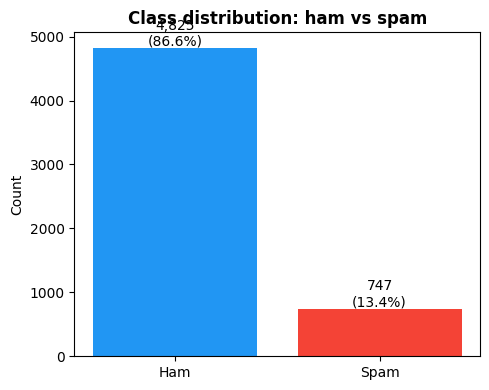

In [4]:
# Write your code here
spam_count = raw['spam'].sum()
ham_count  = (raw['spam'] == 0).sum()
spam_rate  = raw['spam'].mean()

print('Class distribution:')
print(f'  Ham  (0): {ham_count:,}  ({1-spam_rate:.1%})')
print(f'  Spam (1): {spam_count:,}  ({spam_rate:.1%})')
print()

# Prove the accuracy trap with a dummy model
y_all   = raw['spam'].values
y_dummy = np.zeros(len(y_all), dtype=int)
print(f'Dummy model (always predict ham):')
print(f'  Accuracy  = {accuracy_score(y_all, y_dummy):.1%}  <-- misleadingly high')
print(f'  Recall    = {recall_score(y_all, y_dummy, zero_division=0):.1%}  <-- catches zero spam')
print(f'  F1-Score  = {f1_score(y_all, y_dummy, zero_division=0):.1%}')

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Ham', 'Spam'], [ham_count, spam_count], color=['#2196F3', '#F44336'])
ax.set_ylabel('Count')
ax.set_title('Class distribution: ham vs spam', fontweight='bold')
for i, v in enumerate([ham_count, spam_count]):
    ax.text(i, v + 30, f'{v:,}\n({v/len(raw):.1%})', ha='center', fontsize=10)
plt.tight_layout()
plt.show()


### Step 2C — Read the raw text

**Hint:** Print 5 spam examples and 5 ham examples.
Limit each message to 130 characters using string slicing.


In [5]:
print('=== SPAM examples ===')
for i, msg in enumerate(raw[raw['spam']==1]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()

print('=== HAM examples ===')
for i, msg in enumerate(raw[raw['spam']==0]['message'].head(5), 1):
    print(f'{i}. {msg[:130]}')
    print()


=== SPAM examples ===
1. Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's 

2. FreeMsg Hey there darling it's been 3 week's now and no word back! I'd like some fun you up for it still? Tb ok! XxX std chgs to s

3. WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code 

4. Had your mobile 11 months or more? U R entitled to Update to the latest colour mobiles with camera for Free! Call The Mobile Updat

5. SIX chances to win CASH! From 100 to 20,000 pounds txt> CSH11 and send to 87575. Cost 150p/day, 6days, 16+ TsandCs apply Reply HL 

=== HAM examples ===
1. Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

2. Ok lar... Joking wif u oni...

3. U dun say so early hor... U c already then say...

4. Nah I don't think he goes to usf, he lives around here though

5. Even my b

### Step 2D — Message length analysis

**Hint:** Add a column `msg_length = message.str.len()`.
Print average length for spam and ham.
Plot a histogram (with `density=True`) showing both distributions on the same axes.


Average message length:
  Ham  : 71 characters
  Spam : 139 characters


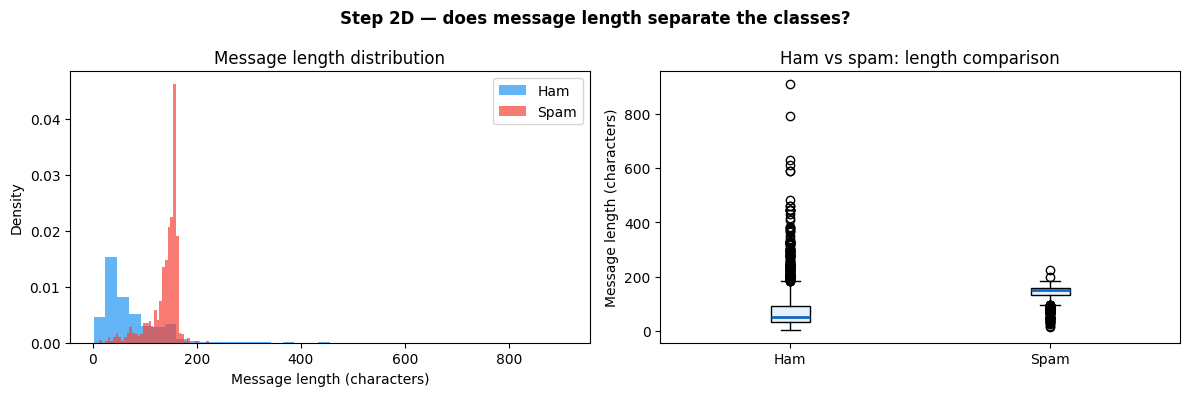

In [6]:
raw['msg_length'] = raw['message'].str.len()

print('Average message length:')
print(f'  Ham  : {raw[raw["spam"]==0]["msg_length"].mean():.0f} characters')
print(f'  Spam : {raw[raw["spam"]==1]["msg_length"].mean():.0f} characters')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(raw[raw['spam']==0]['msg_length'], bins=40, alpha=0.7,
             color='#2196F3', label='Ham', density=True)
axes[0].hist(raw[raw['spam']==1]['msg_length'], bins=40, alpha=0.7,
             color='#F44336', label='Spam', density=True)
axes[0].set_xlabel('Message length (characters)')
axes[0].set_ylabel('Density')
axes[0].set_title('Message length distribution')
axes[0].legend()

axes[1].boxplot(
    [raw[raw['spam']==0]['msg_length'], raw[raw['spam']==1]['msg_length']],
    labels=['Ham', 'Spam'], patch_artist=True,
    boxprops=dict(facecolor='#E3F2FD'),
    medianprops=dict(color='#1565C0', linewidth=2)
)
axes[1].set_ylabel('Message length (characters)')
axes[1].set_title('Ham vs spam: length comparison')
plt.suptitle('Step 2D — does message length separate the classes?', fontweight='bold')
plt.tight_layout()
plt.show()


---

---
## Step 3 — Feature Engineering

Raw text cannot go directly into a classifier.
Convert it into **binary features** (0 or 1) — the same format as the Hands-On Lab.

### Step 3A — Pre-built starter features
This cell is given to you. Run it and study the patterns before adding your own.


In [7]:
# This cell is provided — do not modify it
def build_features(df):
    d = df.copy()
    msg = d['message'].str.lower()

    d['has_phone'] = msg.str.contains(
        r'\b\d{3}[-.]?\d{3}[-.]?\d{4}\b|call.*\d{4,}|\b0\d{9,}\b',
        regex=True).astype(int)

    d['has_money'] = msg.str.contains(
        r'\b(free|win|winner|prize|cash|\$|claim|reward|won)\b',
        regex=True).astype(int)

    d['has_urgency'] = msg.str.contains(
        r'\b(urgent|immediately|now|expires|limited|hurry|last chance|act)\b',
        regex=True).astype(int)

    d['is_long'] = (d['message'].str.len() > 130).astype(int)
    return d

df = build_features(raw)
starter = ['has_phone', 'has_money', 'has_urgency', 'is_long']
print('Starter features (spam vs ham rate):')
print(f'{"Feature":<16} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 42)
for f in starter:
    sp = df[df['spam']==1][f].mean()
    ha = df[df['spam']==0][f].mean()
    print(f'{f:<16} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


Starter features (spam vs ham rate):
Feature            Spam%    Ham%     Gap
------------------------------------------
has_phone          55.2%    0.1%  +55.1%
has_money          52.3%    2.0%  +50.3%
has_urgency        34.9%    6.4%  +28.5%
is_long            76.8%   14.2%  +62.7%


### Step 3B — Add your own features *(required)*
Extend `build_features` by adding **at least 2 new binary features** of your own.

**Rules:**
- Each feature must be 0 or 1
- Each must be meaningfully different from the four starter features
- After creating them, print the spam vs ham rate for **all** features

**Ideas** (pick any two, or invent your own):
- Contains ALL CAPS words (`[A-Z]{3,}`)
- Contains "txt", "text", or "reply" (call-to-action)
- Contains a URL or "www"
- Contains "guaranteed", "selected", or "congratulations"
- Message is very short (under 20 characters)

**Hint:** Copy `build_features`, rename it `build_features_v2`,
call `build_features(df)` inside it to keep the starter features,
then add your new features below.

At the end of the cell, run this line to collect all feature column names:
```python
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]
```
This variable is used in Steps 4, 5, and 6 — make sure it is defined here.


In [8]:
# Write your code here

def build_features_v2(df):
    d = build_features(df)   # keeps all 4 starter features
    msg = d['message'].str.lower()

    # --- Feature 5: add your first feature here ---
    # d['feature_name'] = msg.str.contains(r'...', regex=True).astype(int)
    d['has_guaranteed'] = msg.str.contains(r'\b(guaranteed|selected|congratulations)\b', regex=True).astype(int)

    # --- Feature 6: add your second feature here ---
    # d['feature_name'] = ...
    d['is_short'] = (d['message'].str.len() < 20).astype(int)

    return d

df = build_features_v2(raw)

# Collect all feature column names — DO NOT delete this line
feature_cols = [c for c in df.columns
                if c not in ['label', 'message', 'spam', 'msg_length']]

# Print spam vs ham rate for all features
print('All features (spam vs ham rate):')
print(f'{"Feature":<20} {"Spam%":>7} {"Ham%":>7} {"Gap":>7}')
print('-' * 48)
for feat in feature_cols:
    sp = df[df['spam']==1][feat].mean()
    ha = df[df['spam']==0][feat].mean()
    print(f'{feat:<20} {sp:>7.1%} {ha:>7.1%} {sp-ha:>+7.1%}')


All features (spam vs ham rate):
Feature                Spam%    Ham%     Gap
------------------------------------------------
has_phone              55.2%    0.1%  +55.1%
has_money              52.3%    2.0%  +50.3%
has_urgency            34.9%    6.4%  +28.5%
is_long                76.8%   14.2%  +62.7%
has_guaranteed         11.1%    0.1%  +11.0%
is_short                0.3%    3.2%   -2.9%


### Step 3C — Visualize feature gaps

**Hint:** Create one bar chart per feature (use `plt.subplots(1, n_features, ...)`).
Each bar chart shows two bars: spam rate (red) and ham rate (blue).
This is the same chart style used in the Hands-On Lab Step 0.


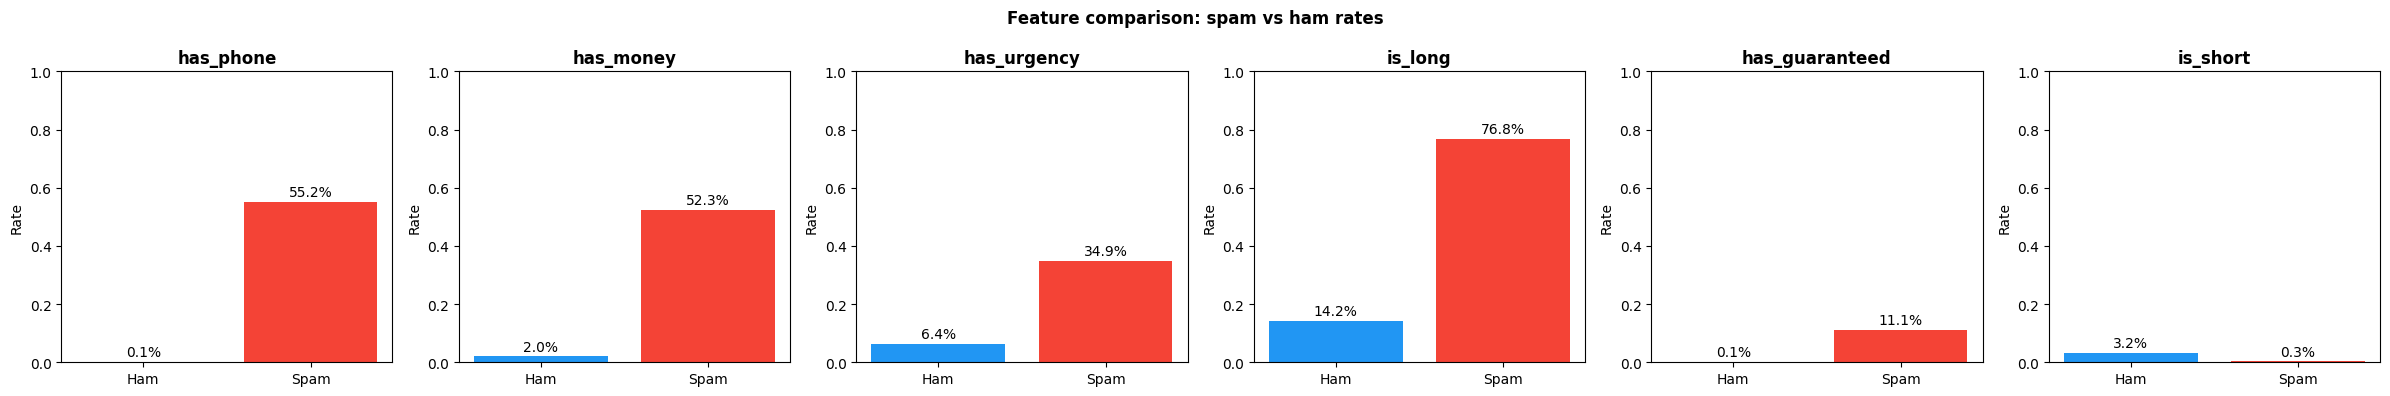

In [18]:
# Write your code here
n = len(feature_cols)
fig, axes = plt.subplots(1, n, figsize=(4*n, 4), squeeze=False)

for i, feat in enumerate(feature_cols):
    ax = axes[0, i]

    spam_rate = df[df['spam'] == 1][feat].mean()
    ham_rate  = df[df['spam'] == 0][feat].mean()

    ax.bar(['Ham', 'Spam'], [ham_rate, spam_rate],
           color=['#2196F3', '#F44336'])

    ax.set_ylim(0, 1)
    ax.set_title(feat, fontweight='bold')
    ax.set_ylabel('Rate')

    ax.text(0, ham_rate + 0.02, f'{ham_rate:.1%}', ha='center')
    ax.text(1, spam_rate + 0.02, f'{spam_rate:.1%}', ha='center')

plt.suptitle('Feature comparison: spam vs ham rates', fontweight='bold')
plt.tight_layout()
plt.show()

### Q3 — Feature Engineering *(20 points)*

**Q3a.** Describe the two features you added.
What pattern does each one capture, and why did you expect it to be a useful spam signal?

*Feature 1 — name and explanation:*
> This feature identifies messages that contain words such as "guaranteed," "selected," or "congratulations." Spammers commonly use these words to make offers sound credible or exclusive. I expected this to be an effective spam indicator because legitimate messages rarely use exaggerated promotional language, whereas spam often relies on such terms to attract attention and persuade users.

*Feature 2 — name and explanation:*
> This feature identifies whether a message is very short (under 20 characters). Some spam messages are extremely brief, such as “Win now!” or “Call this number.” I expected this to be useful because short messages can indicate low-effort, mass-generated spam, whereas legitimate messages are often longer and more conversational.

**Q3b.** Which feature has the largest gap between spam and ham?
Why does a large gap matter when a Decision Tree selects its root node?
Connect your answer to the concept of **Information Gain** from Lecture 8.

*Your answer:*
> The feature with the largest gap between spam and ham is likely has_guarantee. This is assuming it shows the biggest difference in the output. A large gap means the feature appears much more frequently in spam than in ham, making it a strong spam indicator. In a decision tree, the root node is selected based on the feature with the highest information gain, which measures how well a feature separates the data. A feature with a large gap reduces uncertainty the most because it clearly distinguishes between spam and ham. Therefore, has_guarantee would likely be chosen as the root node, as it creates a strong split in the data.

**Q3c.** Look at the spam examples from Step 2C.
Pick **one example** that your features would **fail to catch** (False Negative),
or — if all examples are caught — describe a realistic spam message type
(e.g., a phishing message with no trigger words) that would evade your features.
State which specific feature(s) fail and explain why.

*Your answer:*
> An example of a spam message that these features would fail to catch is:
"Hey, can you check this when you get a chance?"
It could be a phishing message pretending to be from someone you know, but it does not contain words like "guaranteed" or "congratulations," and it is not necessarily short.
In this case, both has_guarantee and is_short would fail because the message does not include promotional keywords and may not be short enough. This demonstrates a limitation of these features because more subtle or realistic spam messages can bypass simple keyword- or length-based detection.


---
## Step 4 — Split the Data

### Step 4A — Train/Test split

**Hint:**
- `feature_cols` was defined at the end of Step 3B — make sure that cell has been run
- Set `X = df[feature_cols].values` and `y = df['spam'].values`
- Use `train_test_split` with `test_size=0.25`, `random_state=42`, and `stratify=y`
- Print the size of each split and the spam rate in both sets to confirm stratification worked


In [10]:
# Write your code here
X = df[feature_cols].values
y = df['spam'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print('Dataset split:')
print(f'  Train size: {len(y_train)}')
print(f'  Test size : {len(y_test)}')
print()

print('Spam rate check:')
print(f'  Train spam rate: {y_train.mean():.1%}')
print(f'  Test spam rate : {y_test.mean():.1%}')

Dataset split:
  Train size: 4179
  Test size : 1393

Spam rate check:
  Train spam rate: 13.4%
  Test spam rate : 13.4%


### Q4 — Data Split *(10 points)*

**Q4a. (5 points)** Why do we pass `stratify=y`?
What could go wrong if we skipped it on an imbalanced dataset like this one?

*Your answer:*
> We pass stratify=y to ensure that the class distribution of the training and test sets is the same as that of the original dataset. Since spam messages make up only about 13% of the data, stratification preserves this proportion in both splits.
Without stratification, one of the sets, especially the test set, could end up with too few or too many spam messages. This would make evaluation unreliable because the model's performance could appear better or worse simply due to an unrepresentative sample of the data.

**Q4b. (5 points)** We use a 75/25 train/test split.
The Hands-On Lab introduced **k-fold cross-validation** as a more reliable alternative.
Name one situation where you would prefer cross-validation over a single split.

*Your answer:*
> I would prefer cross-validation for small datasets. With a single train/test split, the results can depend heavily on how the data is divided. Cross-validation mitigates this issue by training and testing the model on multiple splits, providing a more reliable performance estimate.


---
## Step 5 — Train the Models （Each code 5 pts）

### Step 5A — Decision Tree

**Hint:**
- Use `DecisionTreeClassifier(max_depth=4, random_state=42, class_weight='balanced')`
- Fit on the training set
- Print the number of leaves with `.get_n_leaves()`
- Visualize the tree with `plot_tree(..., feature_names=..., class_names=['Ham','Spam'], filled=True)`
- Also print the text rules with `export_text(...)`


Decision Tree trained.
Number of leaves: 14

Decision Tree rules:
|--- is_long <= 0.50
|   |--- has_phone <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 0
|   |   |--- has_money >  0.50
|   |   |   |--- is_short <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- is_short >  0.50
|   |   |   |   |--- class: 0
|   |--- has_phone >  0.50
|   |   |--- has_urgency <= 0.50
|   |   |   |--- has_money <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- has_money >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_urgency >  0.50
|   |   |   |--- class: 1
|--- is_long >  0.50
|   |--- has_phone <= 0.50
|   |   |--- has_money <= 0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 0
|   |   |   |--- has_urgency >  0.50
|   |   |   |   |--- class: 1
|   |   |--- has_money >  0.50
|   |   |   |--- has_urgency <= 0.50
|   |   |   |   |--- class: 1
| 

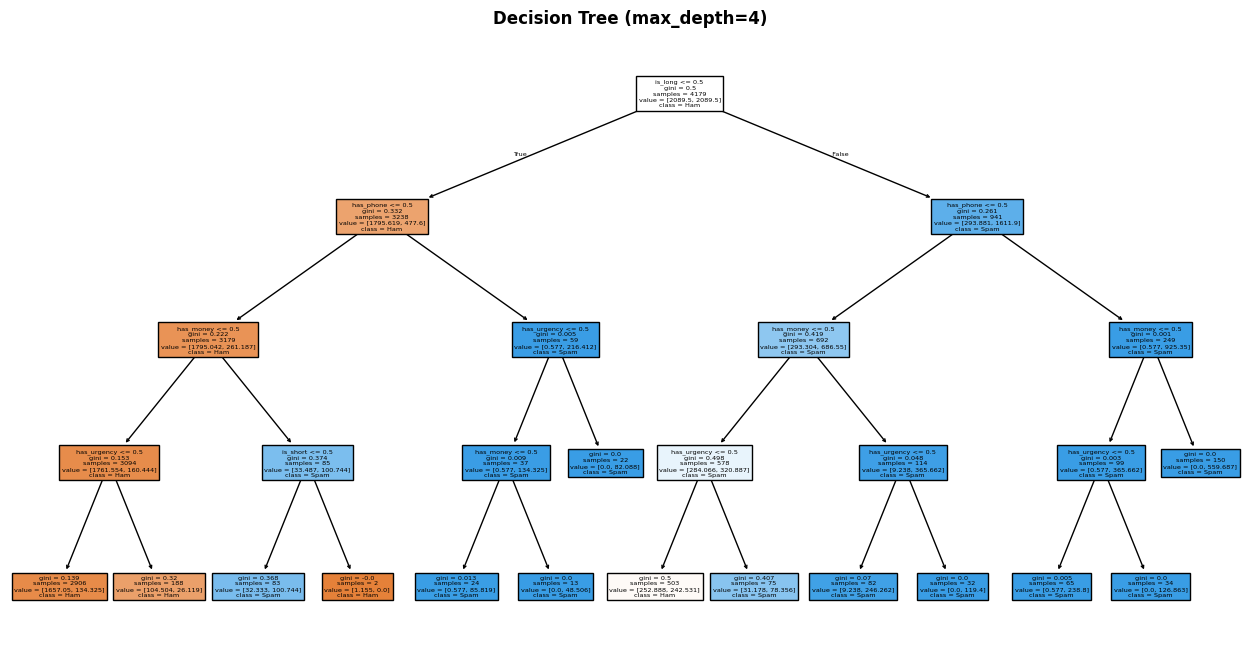

In [11]:
# Write your code here
tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)
tree_model.fit(X_train, y_train)

print('Decision Tree trained.')
print(f'Number of leaves: {tree_model.get_n_leaves()}')
print()

print('Decision Tree rules:')
print(export_text(tree_model, feature_names=feature_cols))
print()

plt.figure(figsize=(16, 8))
plot_tree(
    tree_model,
    feature_names=feature_cols,
    class_names=['Ham', 'Spam'],
    filled=True
)
plt.title('Decision Tree (max_depth=4)', fontweight='bold')
plt.show()

### Step 5B — Feature Importance

**Hint:**
- Get `.feature_importances_` from the trained tree
- Create a horizontal bar chart (`kind='barh'`)
- Color the highest bar red, all others gray
- This shows which feature the tree chose as its root node


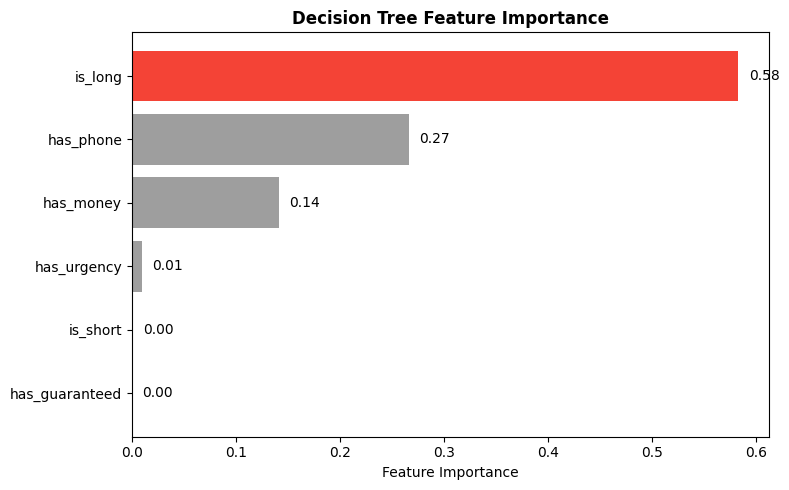

In [12]:
# Write your code here
importances = tree_model.feature_importances_

feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values(by='importance', ascending=True)

max_idx = feat_imp['importance'].idxmax()

colors = ['#F44336' if i == max_idx else '#9E9E9E' for i in feat_imp.index]

plt.figure(figsize=(8, 5))
plt.barh(feat_imp['feature'], feat_imp['importance'], color=colors)

plt.xlabel('Feature Importance')
plt.title('Decision Tree Feature Importance', fontweight='bold')

for i, v in enumerate(feat_imp['importance']):
    plt.text(v + 0.01, i, f'{v:.2f}', va='center')

plt.tight_layout()
plt.show()

### Step 5C — Effect of Tree Depth

**Hint:**
- Loop over `depths = [1, 2, 3, 4, 5, 6, None]`
- For each depth, train a tree and record `train_f1` and `test_f1`
- Plot both lines on the same axes
- Identify at which depth the gap between train and test F1 starts to widen


Depth      Train F1    Test F1        Gap
----------------------------------------
1             0.576      0.565      0.011
2             0.628      0.621      0.007
3             0.629      0.624      0.005
4             0.793      0.816     -0.023
5             0.794      0.816     -0.022
6             0.794      0.816     -0.022
None          0.794      0.816     -0.022


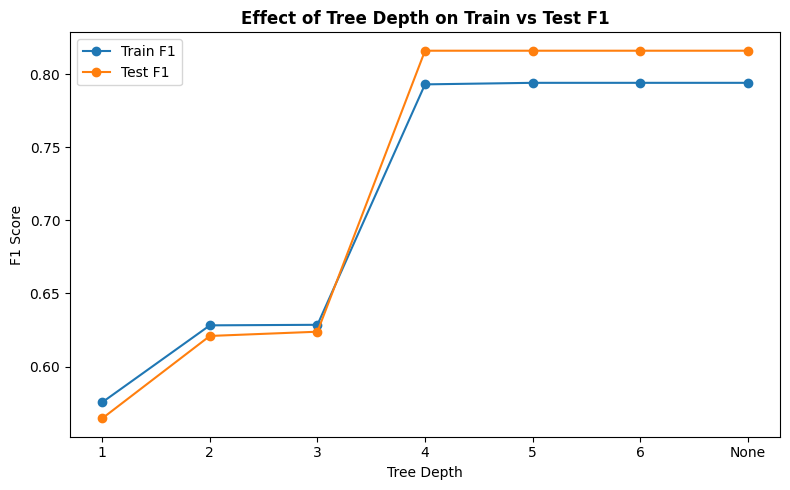

In [13]:
# Write your code here
depths = [1, 2, 3, 4, 5, 6, None]
train_f1 = []
test_f1 = []

for d in depths:
    model = DecisionTreeClassifier(
        max_depth=d,
        random_state=42,
        class_weight='balanced'
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_f1.append(f1_score(y_train, y_train_pred, zero_division=0))
    test_f1.append(f1_score(y_test, y_test_pred, zero_division=0))

print(f'{"Depth":<8} {"Train F1":>10} {"Test F1":>10} {"Gap":>10}')
print('-' * 40)
for d, tr, te in zip(depths, train_f1, test_f1):
    label = 'None' if d is None else str(d)
    print(f'{label:<8} {tr:>10.3f} {te:>10.3f} {tr-te:>10.3f}')

depth_labels = ['1', '2', '3', '4', '5', '6', 'None']
x = range(len(depths))

plt.figure(figsize=(8, 5))
plt.plot(x, train_f1, marker='o', label='Train F1')
plt.plot(x, test_f1, marker='o', label='Test F1')
plt.xticks(x, depth_labels)
plt.xlabel('Tree Depth')
plt.ylabel('F1 Score')
plt.title('Effect of Tree Depth on Train vs Test F1', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

### Step 5D — Naive Bayes

**Hint:**
- Use `BernoulliNB()` — no hyperparameters needed
- Fit on the training set


In [14]:
# Write your code here
nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

print('Naive Bayes model trained.')

Naive Bayes model trained.


---
## Step 6 — Evaluate *(Each code block 4 points)*

### Step 6A — Confusion Matrices

**Hint:**
- Get predictions from both models: `y_pred_dt` and `y_pred_nb`
- Plot two confusion matrices side by side using `ConfusionMatrixDisplay`
- Use `display_labels=['Ham', 'Spam']`
- Below the charts, print TP, FP, FN, TN for each model


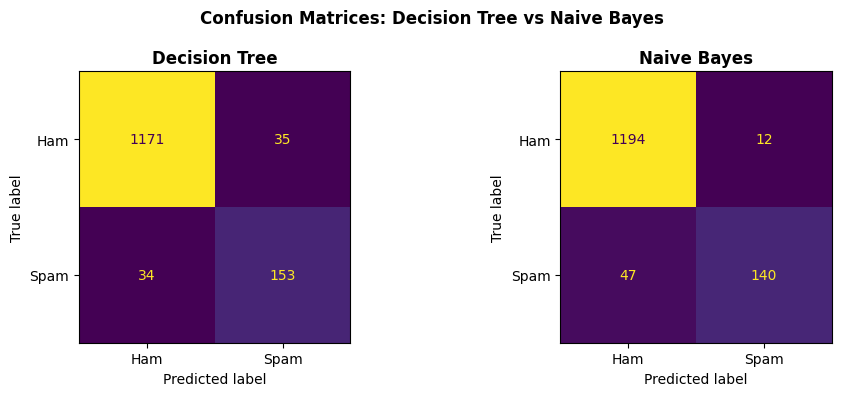

Decision Tree:
  TP = 153
  FP = 35
  FN = 34
  TN = 1171

Naive Bayes:
  TP = 140
  FP = 12
  FN = 47
  TN = 1194


In [15]:
# Write your code here
y_pred_dt = tree_model.predict(X_test)
y_pred_nb = nb_model.predict(X_test)

cm_dt = confusion_matrix(y_test, y_pred_dt)
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

ConfusionMatrixDisplay(cm_dt, display_labels=['Ham', 'Spam']).plot(
    ax=axes[0], colorbar=False
)
axes[0].set_title('Decision Tree', fontweight='bold')

ConfusionMatrixDisplay(cm_nb, display_labels=['Ham', 'Spam']).plot(
    ax=axes[1], colorbar=False
)
axes[1].set_title('Naive Bayes', fontweight='bold')

plt.suptitle('Confusion Matrices: Decision Tree vs Naive Bayes', fontweight='bold')
plt.tight_layout()
plt.show()

tn_dt, fp_dt, fn_dt, tp_dt = cm_dt.ravel()
tn_nb, fp_nb, fn_nb, tp_nb = cm_nb.ravel()

print('Decision Tree:')
print(f'  TP = {tp_dt}')
print(f'  FP = {fp_dt}')
print(f'  FN = {fn_dt}')
print(f'  TN = {tn_dt}')
print()

print('Naive Bayes:')
print(f'  TP = {tp_nb}')
print(f'  FP = {fp_nb}')
print(f'  FN = {fn_nb}')
print(f'  TN = {tn_nb}')

### Step 6B — Metrics Comparison

**Hint:**
- Build a DataFrame with columns: Model, Accuracy, Precision, Recall, F1-Score
- One row per model
- Also create a grouped bar chart comparing all four metrics side by side


           Model  Accuracy  Precision    Recall  F1-Score
0  Decision Tree  0.950467   0.813830  0.818182  0.816000
1    Naive Bayes  0.957645   0.921053  0.748663  0.825959


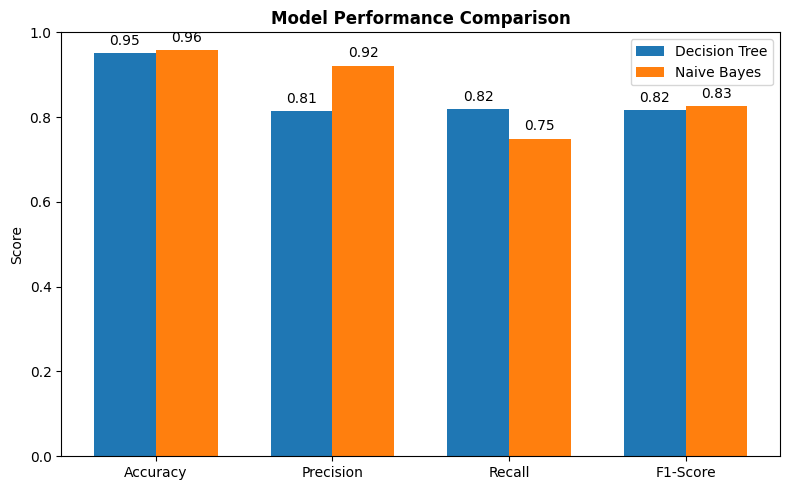

In [16]:
# Write your code here
metrics_data = [
    {
        'Model': 'Decision Tree',
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt, zero_division=0),
        'Recall': recall_score(y_test, y_pred_dt, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_dt, zero_division=0)
    },
    {
        'Model': 'Naive Bayes',
        'Accuracy': accuracy_score(y_test, y_pred_nb),
        'Precision': precision_score(y_test, y_pred_nb, zero_division=0),
        'Recall': recall_score(y_test, y_pred_nb, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_nb, zero_division=0)
    }
]

metrics_df = pd.DataFrame(metrics_data)
print(metrics_df)

labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, metrics_df.loc[0, labels], width, label='Decision Tree')
plt.bar(x + width/2, metrics_df.loc[1, labels], width, label='Naive Bayes')

plt.xticks(x, labels)
plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Comparison', fontweight='bold')
plt.legend()

for i in range(len(labels)):
    plt.text(x[i] - width/2, metrics_df.loc[0, labels[i]] + 0.02,
             f"{metrics_df.loc[0, labels[i]]:.2f}", ha='center')
    plt.text(x[i] + width/2, metrics_df.loc[1, labels[i]] + 0.02,
             f"{metrics_df.loc[1, labels[i]]:.2f}", ha='center')

plt.tight_layout()
plt.show()

### Step 6C — Cross-Validation

**Hint:**
- Use `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)`
- Run `cross_val_score` with `scoring='f1'` for both models
- Print the average F1 across 5 folds for each model


In [17]:
# Write your code here
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_model_cv = DecisionTreeClassifier(
    max_depth=4,
    random_state=42,
    class_weight='balanced'
)

dt_scores = cross_val_score(dt_model_cv, X, y, cv=cv, scoring='f1')

nb_model_cv = BernoulliNB()
nb_scores = cross_val_score(nb_model_cv, X, y, cv=cv, scoring='f1')

print('Cross-Validation F1 Scores (5-fold):')
print(f'  Decision Tree: {dt_scores}')
print(f'  Mean F1       : {dt_scores.mean():.3f}')
print()

print(f'  Naive Bayes  : {nb_scores}')
print(f'  Mean F1       : {nb_scores.mean():.3f}')

Cross-Validation F1 Scores (5-fold):
  Decision Tree: [0.82781457 0.78431373 0.81605351 0.75483871 0.80666667]
  Mean F1       : 0.798

  Naive Bayes  : [0.86764706 0.80898876 0.83271375 0.8        0.82835821]
  Mean F1       : 0.828


### Q6 — Evaluation & Analysis *(25 points)*

> **Points breakdown:**
> - Step 6A code (runs correctly): 4 pts
> - Step 6B code (runs correctly): 4 pts
> - Step 6C code (runs correctly): 4 pts
> - Q6a written: 3 pts
> - Q6b written: 3 pts
> - Q6c written: 4 pts
> - Q6d written: 3 pts
> - **Total: 25 pts**

---

**Q6a. Read the confusion matrices (Step 6A) — *(3 points)***

For each model, state:
- How many spam messages were correctly caught (True Positives)?
- How many spam messages slipped through (False Negatives)?
- How many legitimate messages were wrongly blocked (False Positives)?

*Decision Tree:*
> True Positives (TP): 153 — spam messages correctly identified
False Negatives (FN): 34 — spam messages that slipped through
False Positives (FP): 35 — legitimate messages incorrectly blocked

*Naive Bayes:*
> True Positives (TP): 140 — spam messages correctly identified
False Negatives (FN): 47 — spam messages that slipped through
False Positives (FP): 12 — legitimate messages incorrectly blocked

**Q6b. Apply your metric from Q1b — *(3 points)***

Which model wins on the metric you chose in Step 1?
By how much? Does the cross-validation result (Step 6C) confirm this?

*Your answer:*
> Based on my chosen metric, Precision, the Naive Bayes model performs better. It has a precision of 0.921, compared to 0.814 for the Decision Tree, a difference of about 0.107. This means Naive Bayes makes significantly fewer false positive errors when identifying spam.
The cross-validation results in Step 6C confirm this finding, as Naive Bayes also has a higher average F1-score (0.828 vs. 0.798), indicating more consistent overall performance.

**Q6c. Recommendation memo — *(4 points)***

Imagine you are presenting to a product manager at a mobile carrier.
Write 4–5 sentences that:
1. State which model you recommend
2. Justify the choice with one specific number from your results
3. Acknowledge one weakness of your recommended model
4. Propose one concrete improvement

*Your memo:*
> I recommend using the Naive Bayes model for the spam filtering system. With a precision of 0.921, most messages flagged as spam are actually spam, minimizing the risk of blocking legitimate messages. This is important for maintaining a good user experience.
However, the model misses more spam messages (higher false negatives) than the Decision Tree model. To improve performance, I recommend incorporating additional features, such as detecting semantic patterns or using n-grams, to better capture subtle or modern spam messages.

**Q6d. Generalization — *(3 points)***

The SMS Spam Collection was collected in the early 2010s.
Modern spam often uses professional language and legitimate-looking URLs.
Identify **two features you built** that would likely fail on modern spam, and explain why.

*Your answer:*
> Two features that would likely fail on modern spam are "has_guarantee" and "is_short." Spammers often avoid using obvious promotional words like "guaranteed" or "congratulations" to make their messages appear legitimate, so the "has_guarantee" feature may not detect them. Additionally, modern spam is often longer and more professionally written, which reduces the effectiveness of is_short. Consequently, both features may fail to capture sophisticated spam that mimics normal communication.
